# 📈 Pairs Trading — Empirical Methods in Finance
---
**Project 1** | Hotel Industry Stocks | 2010–2025

> **Objective:** Identify cointegrated pairs of stocks in the hotel sector and exploit the mean-reverting behaviour of their spread for a pairs trading strategy.

---

## 📥 Step 1 — Download Data of Interest

We will use data downloaded from **yfinance**. The data we download is from the **Hotel industry**. We download 5 different stocks for this project:

| Ticker | Company |
|--------|---------|
| `BKNG` | Booking Holdings |
| `H` | Hyatt Hotels |
| `HLT` | Hilton Worldwide |
| `MAR` | Marriott International |
| `IHG` | InterContinental Hotels Group |

In [ ]:
# --- Imports ---
from main import Fetch_Data
from main import Select_Pair
from main import Fetch_wrds
from main import Simple_Pair_Trading
from main import Rolling_Pair_Trading
import matplotlib.pyplot as plt
import numpy as np
from utils import plot_n_series, plot_wealth_positions_spread
import pandas as pd


In [2]:
start_date = '2010-01-01'
end_date = '2025-01-01'
tickers = ['IHG', 'HLT', 'MAR', 'BKNG', 'H']

In [3]:
# --- Download & log-transform prices ---
fetcher = Fetch_Data(start_date, end_date, tickers)
data_raw   = fetcher.download_data()

/Users/mpecaut/Empirical-Methods-In-Finance/Project1/main.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(self.tickers, start = self.start_date, end = self.end_date)
[*********************100%***********************]  5 of 5 completed


In [4]:
data_raw

Ticker,BKNG,H,HLT,IHG,MAR
Date,,,,,
2010-01-04,219.852905,28.976204,NaN,12.650041,21.998896
2010-01-05,222.405197,29.014887,NaN,12.562919,22.126287
2010-01-06,215.062363,28.744083,NaN,12.510645,22.189987
2010-01-07,212.166473,28.908501,NaN,12.641330,22.277569
2010-01-08,212.245010,28.734411,NaN,12.885268,22.325346
...,...,...,...,...,...
2024-12-24,5073.581055,157.784744,252.564148,123.299652,283.074402
2024-12-26,5046.940918,158.670166,251.068268,123.426208,283.242401
2024-12-27,4988.856445,157.645477,249.253281,123.007584,280.376007


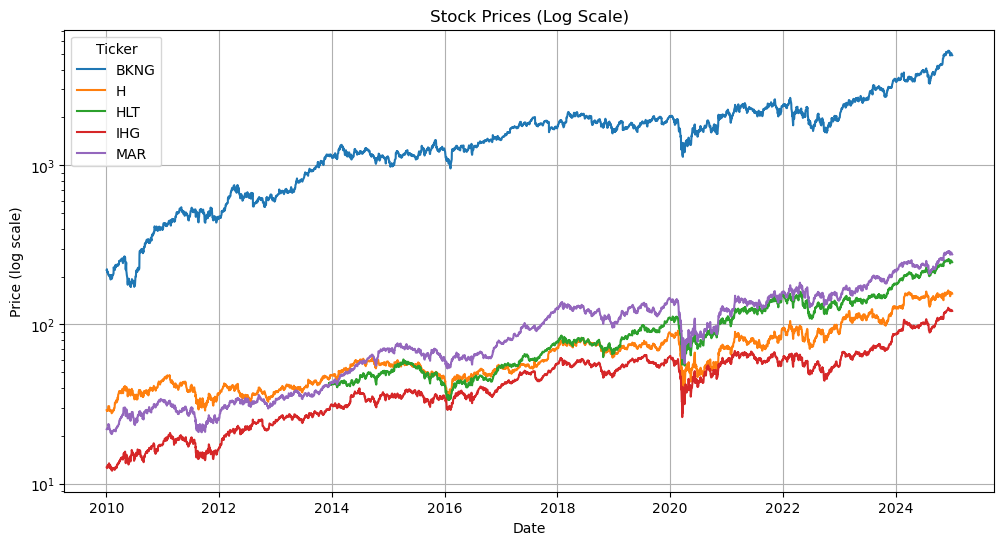

In [5]:
plot_n_series(data_raw,'Stock Prices (Log Scale)','log', 'Date', 'Price (log scale)')

---
## 📊 Step 2 — Stationarity & Cointegration

**Stationarity** means that a serie's two first moments are constant through time along with time-independent autocovariance (covariance of a time series with itself only depends on the lag). This implies that the series does not exhibit any trend or seasonal effect ; it constantly reverts to its mean.

---

It is important to differentiate **cointegration** from **correlation**. Two assets are correlated in the sense that if one moves up, the other will certainly also move up by some amount. Mathematically speaking, correlation measures the short-term linear relationship between two time series. However, this might not imply that the spread between those 2 assets is constant. Indeed, it might even diverge. This is where cointegration comes into play. If two assets are cointegrated, then the spread (the price difference between the 2 assets) will remain constant through time (spread is therefore stationary). This implies that if the spread diverges (goes above or below its normal level), in theory, it should not be long before this value comes back to its average level. This is what we will exploit later on.

For some little more theory, cointegration describes the long-term relationship between two non-stationary time series. While the individual serie might drift (non-stationarity condition), a specific linear combination of them stays near a constant mean.

---

#### 🔬 What does `statsmodels.tsa.stattools.coint` do?

**Step 1 — Regress the two time series.**  
For example, if the first time series is Booking log price and the second one is IHG log price:

$$Booking_t = \alpha + \beta \cdot IHG_t + \epsilon_t$$

| Parameter | Interpretation |
|-----------|---------------|
| $\alpha$ | Price level difference between the two stocks. Since Booking trades at log price ≈ 6–8 and IHG ≈ 2.5–5.5, we expect $\alpha \approx 3$ |
| $\beta$ | How much of Booking's price is explained by IHG — analogous to the CAPM beta. If $\beta = 0.3$, a 1% drop in IHG implies a 0.3% drop in Booking |
| $\epsilon$ | The residual — the part of Booking's price *unexplained* by IHG, capturing the random deviation from the long-run relationship |

**Step 2 — Extract the residuals** and test them for stationarity using an ADF test. If the residuals are stationary, the pair is cointegrated.

In [6]:
data = np.log(data_raw)

In [7]:
# --- Run cointegration test on all permutations ---
pairselect = Select_Pair(data)
permut     = pairselect.permutations()
most_coint_pair, data_most_coint_pair = pairselect.are_cointegrated()

 Most cointegrated pair: BKNG — IHG


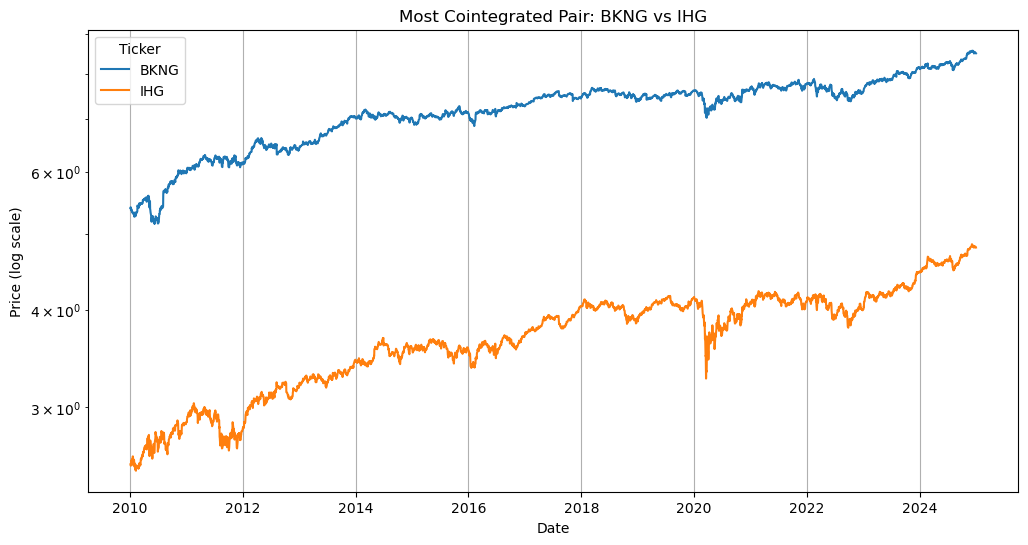

In [8]:
# --- Plot the most cointegrated pair ---
print(f' Most cointegrated pair: {most_coint_pair[0]} — {most_coint_pair[1]}')
plot_n_series(data_most_coint_pair, f'Most Cointegrated Pair: {most_coint_pair[0]} vs {most_coint_pair[1]}', 'log', 'Date', 'Price (log scale)')

### Extract the values alpha,beta and the spread

In [9]:
tickers = [data_most_coint_pair.columns[0],data_most_coint_pair.columns[1]]

alpha,beta,residuals = pairselect.extract_ratios_cointegrated_pair(data_most_coint_pair,tickers)


In [10]:
std_residuals = pairselect.normalize_residuals(residuals)

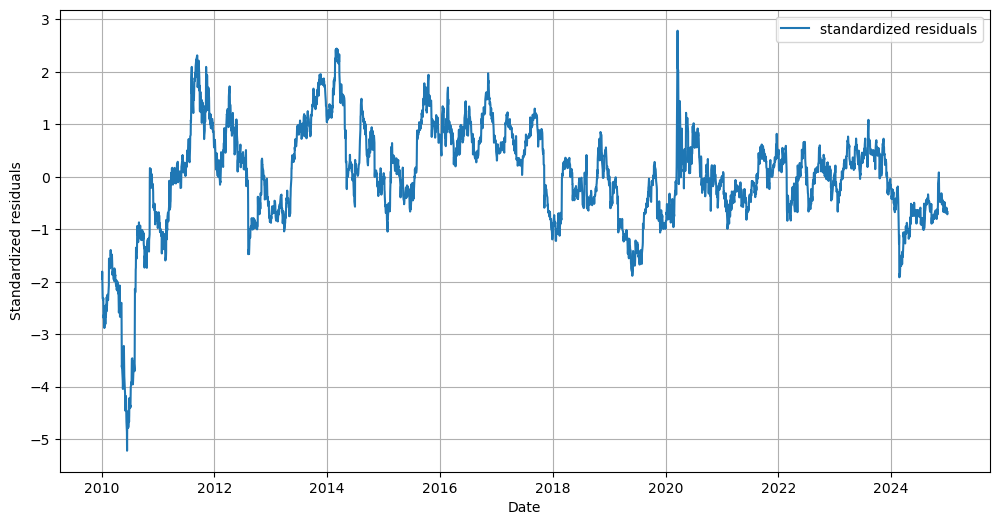

In [11]:
plt.figure(figsize= (12,6))
plt.plot(std_residuals, label = 'standardized residuals')
plt.grid()
plt.xlabel('Date')
plt.ylabel('Standardized residuals')
plt.legend()
plt.show()


---

## 📈 Step 3 — Pair Trading


Now that we have our pair and we have been able to extract its residual and standardize it, we'll implement a first, simple trading strat based on mean reversion of the spread.

Our regression looks like : $$booking_t = \alpha + \beta IHG_t + \epsilon_t$$ therefore, the normalized spread is : $$z_t = \left( (booking_t - \alpha - \beta IHG_t )- \mu (\epsilon_t) \right) / \sigma(\epsilon_t)$$

We will now incorporate the bid-ask spread as well as some transaction costs. What we will do is to also try to find the optimal threshold (the one leading to the highest sharpe ratio) to enter a trade. I will explain that a little bit below but for now, I will go into WRDS database and fetch crsp bid and ask date for BKNG and IHG

In [12]:
start_date = '2010-01-01'
end_date = '2025-02-01'
tickers = ['IHG','BKNG']
username = 'mariuspecaut'
fetch_wrds = Fetch_wrds(start_date, end_date, tickers, username)

In [ ]:
fetch_wrds.create_wrds_connection()
ticker_aliases = {'BKNG': ['BKNG', 'PCLN'],}

bid_ask_spread = fetch_wrds.fetch_bid_ask(ticker_aliases)

Loading library list...
Done


### First, simple trading strat on the whole sample

We have defined the spread as the residual $\varepsilon_t$ which is the part unexplained when regressing asset A on asset B. This spread, which we normalize, should be stationary, it mean-reverts around 0. For visualization purposes, we will test this hypothesis using a Augmented Dickey-Fuller test.

The Null Hypothesis $H_0$ : The time series is not stationary (it has a unique root) ; its mean is not 0. 

In [17]:
p_val,crit_vals = pairselect.test_stationarity()
pairselect.adf_test_results(p_val)

H0 is rejected : the residuals are stationary


In [ ]:
threshold = 1.5

In [ ]:
simplepairtrading = Simple_Pair_Trading(data_raw,data_most_coint_pair,std_residuals,bid_ask_spread,alpha,beta,threshold)
positions = simplepairtrading.simple_pair_trading()

In [ ]:
cumulative_pnl, sharpe_ratio = simplepairtrading.pnl_calculations()

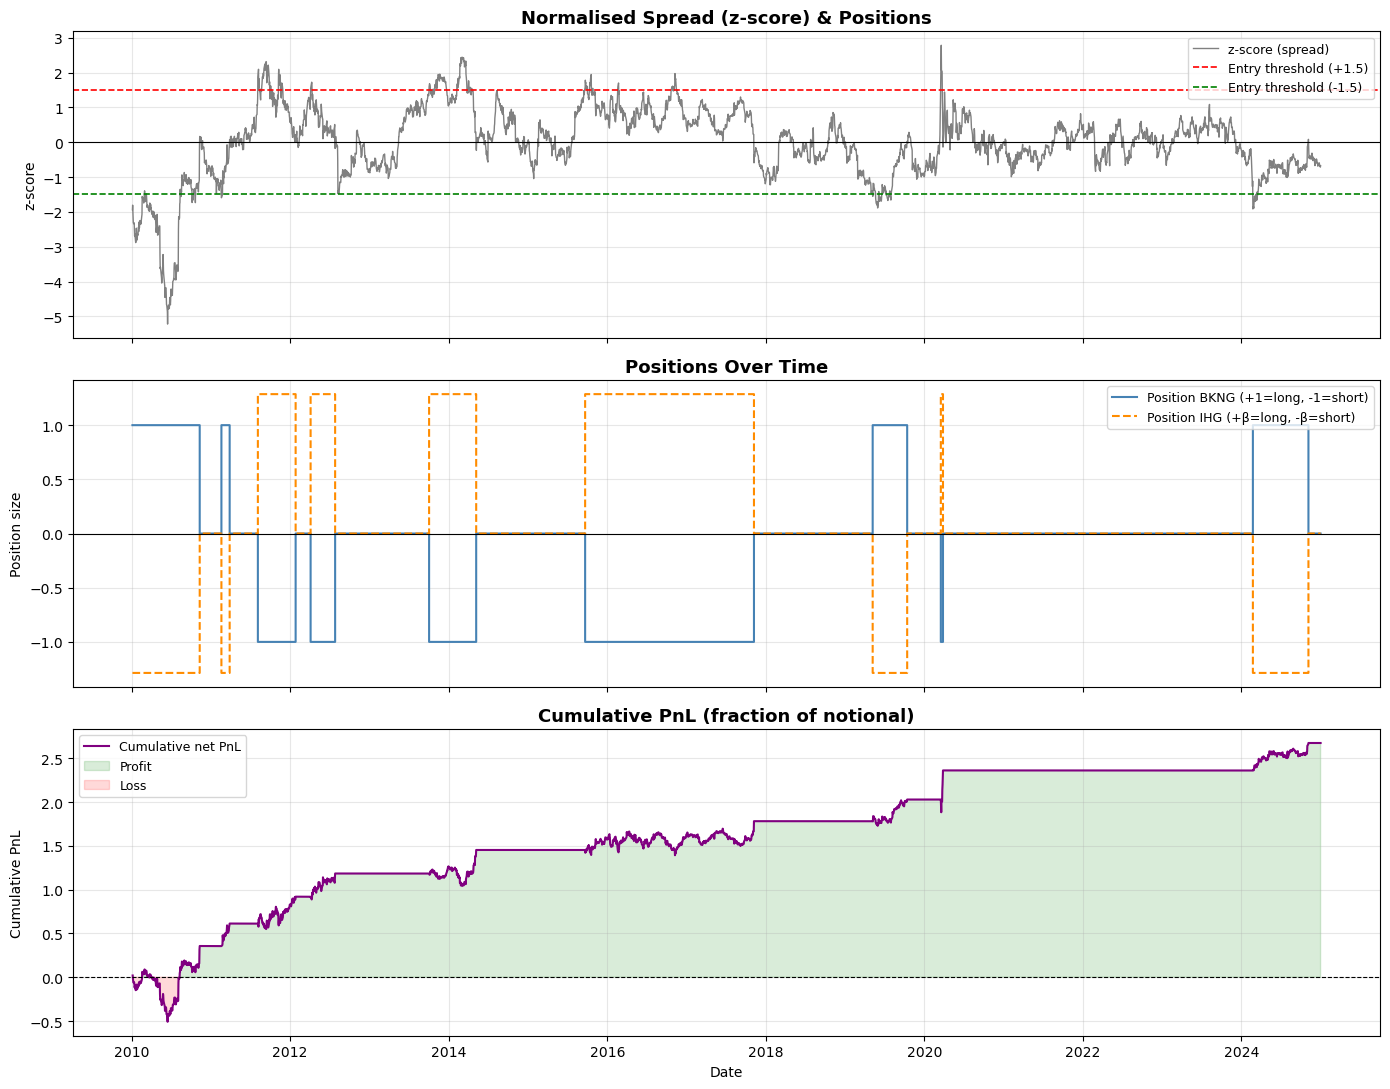

Sharpe ratio (annualised): 0.5648


In [22]:
plot_wealth_positions_spread(data_most_coint_pair, std_residuals, threshold, positions, cumulative_pnl)
print(f"Sharpe ratio (annualised): {sharpe_ratio:.4f}")

---
## Step 5 - Rolling window pair trading strategy 

The previous trading strategy was developed using an estimation of beta based on the whole sample. This is problematic as the position size which is opened at time t depends on beta which depends itself on the whole sample. In practice, this is impossible as we never know what will happen in the future. To overcome this, I will use a rolling window to estimate beta, make decisions and then go forward. 

I will use a rolling windows of 252 days (1 year) to first estimate beta. Then, based on this value, I take decision for tomorrow based on today's spread, where the size I invest in each asset depends on the value of current beta.

In [ ]:
rollingpairtrading = Rolling_Pair_Trading(window = 252, coint_window = 504, data_raw, )

---
## Step 6 — Rolling Window Strategy with Engle-Granger Cointegration Filter

The previous rolling strategy assumed the pair **remains cointegrated throughout the entire sample**. This may not hold in practice — structural breaks (e.g. COVID, financial crises) or fundamental business changes can cause the long-run relationship to break down temporarily.

**Key idea:** Before generating any signal on day $t$, test whether the pair was still cointegrated over the **last 252 trading days** using the Engle-Granger test:

$$H_0: \text{the residual } \varepsilon_t \text{ is non-stationary (no cointegration)}$$

| p-value | Decision |
|---|---|
| $p < 0.05$ | Reject $H_0$ → cointegration confirmed → **trade normally** |
| $p \geq 0.05$ | Fail to reject $H_0$ → cointegration uncertain → **close any open position and stay flat** |

This adds a regime filter on top of the z-score signal: we only exploit mean-reversion when the statistical foundation (cointegration) is confirmed by the data.


Cointegrated windows : 816 / 3270 (25.0%) → trading allowed
Non-cointegrated     : 2454 (75.0%) → forced flat


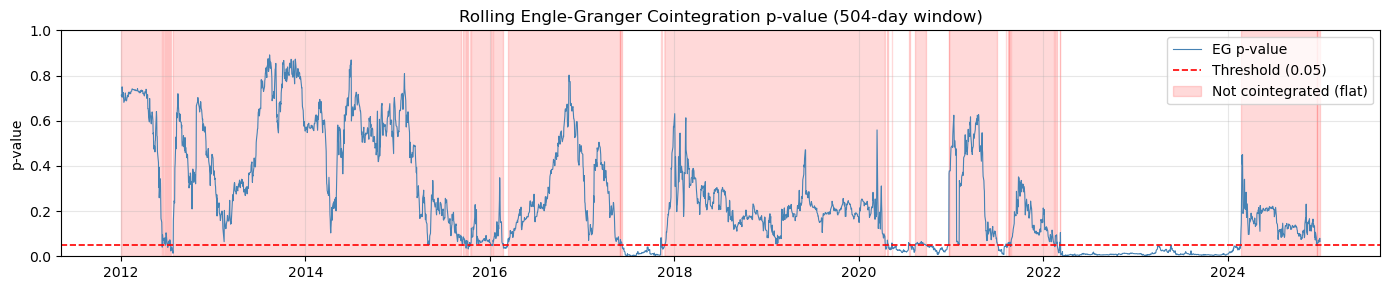

In [41]:
from statsmodels.tsa.stattools import coint as eg_coint

coint_pvalue_threshold = 0.05   # Significance level for the EG test
window_coint = 504              # 2-year window for cointegration test (longer sample = more test power = fewer false "not cointegrated" rejections)
window_beta  = 252              # 1-year window for alpha/beta/z-score (in order to adapt faster to regime changes)

# Storing : we keep the p-values for every day so that I can plot them
rolling_spread_cf  = pd.Series(np.nan, index=data_most_coint_pair.index)
rolling_beta_cf    = pd.Series(np.nan, index=data_most_coint_pair.index)
rolling_coint_pval = pd.Series(np.nan, index=data_most_coint_pair.index)

# Start at window_coint (the larger window) so both sub-windows always have enough data
for t in range(window_coint, n):
    coint_data = data_most_coint_pair.iloc[t - window_coint : t]  # 504-day window for EG test
    beta_data  = data_most_coint_pair.iloc[t - window_beta  : t]  # 252-day window for OLS

    # 1) Engle-Granger cointegration test on the 504-day window
    _, pval, _ = eg_coint(coint_data[ticker_A], coint_data[ticker_B])
    rolling_coint_pval.iloc[t] = pval

    # 2) estimate alpha, beta, spread on the 252-day window
    selectpair_cf = Select_Pair(beta_data)
    alpha_cf, beta_cf, resid_cf = selectpair_cf.extract_ratios_cointegrated_pair(beta_data, tickers_pair)

    # Out-of-sample spread for day t (yesterday's model applied to today's price)
    spread_t = data_most_coint_pair[ticker_A].iloc[t] - alpha_cf - beta_cf * data_most_coint_pair[ticker_B].iloc[t]
    rolling_spread_cf.iloc[t] = (spread_t - resid_cf.mean()) / resid_cf.std()
    rolling_beta_cf.iloc[t]   = beta_cf

# summary 
rolling_coint_pval_clean = rolling_coint_pval.iloc[window_coint:]
n_total = len(rolling_coint_pval_clean)
n_coint = int((rolling_coint_pval_clean < coint_pvalue_threshold).sum())
pct     = 100 * n_coint / n_total
print(f"Cointegrated windows : {n_coint} / {n_total} ({pct:.1f}%) → trading allowed")
print(f"Non-cointegrated     : {n_total - n_coint} ({100 - pct:.1f}%) → forced flat")

# ── Plot rolling p-value ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(rolling_coint_pval_clean.index, rolling_coint_pval_clean.values,
        lw=0.8, color='steelblue', label='EG p-value')
ax.axhline(coint_pvalue_threshold, color='red', lw=1.2, linestyle='--',
           label=f'Threshold ({coint_pvalue_threshold})')
ax.fill_between(rolling_coint_pval_clean.index, 0, 1,
                where=(rolling_coint_pval_clean >= coint_pvalue_threshold),
                alpha=0.15, color='red', label='Not cointegrated (flat)')
ax.set_ylim(0, 1)
ax.set_ylabel('p-value')
ax.set_title(f'Rolling Engle-Granger Cointegration p-value ({window_coint}-day window)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


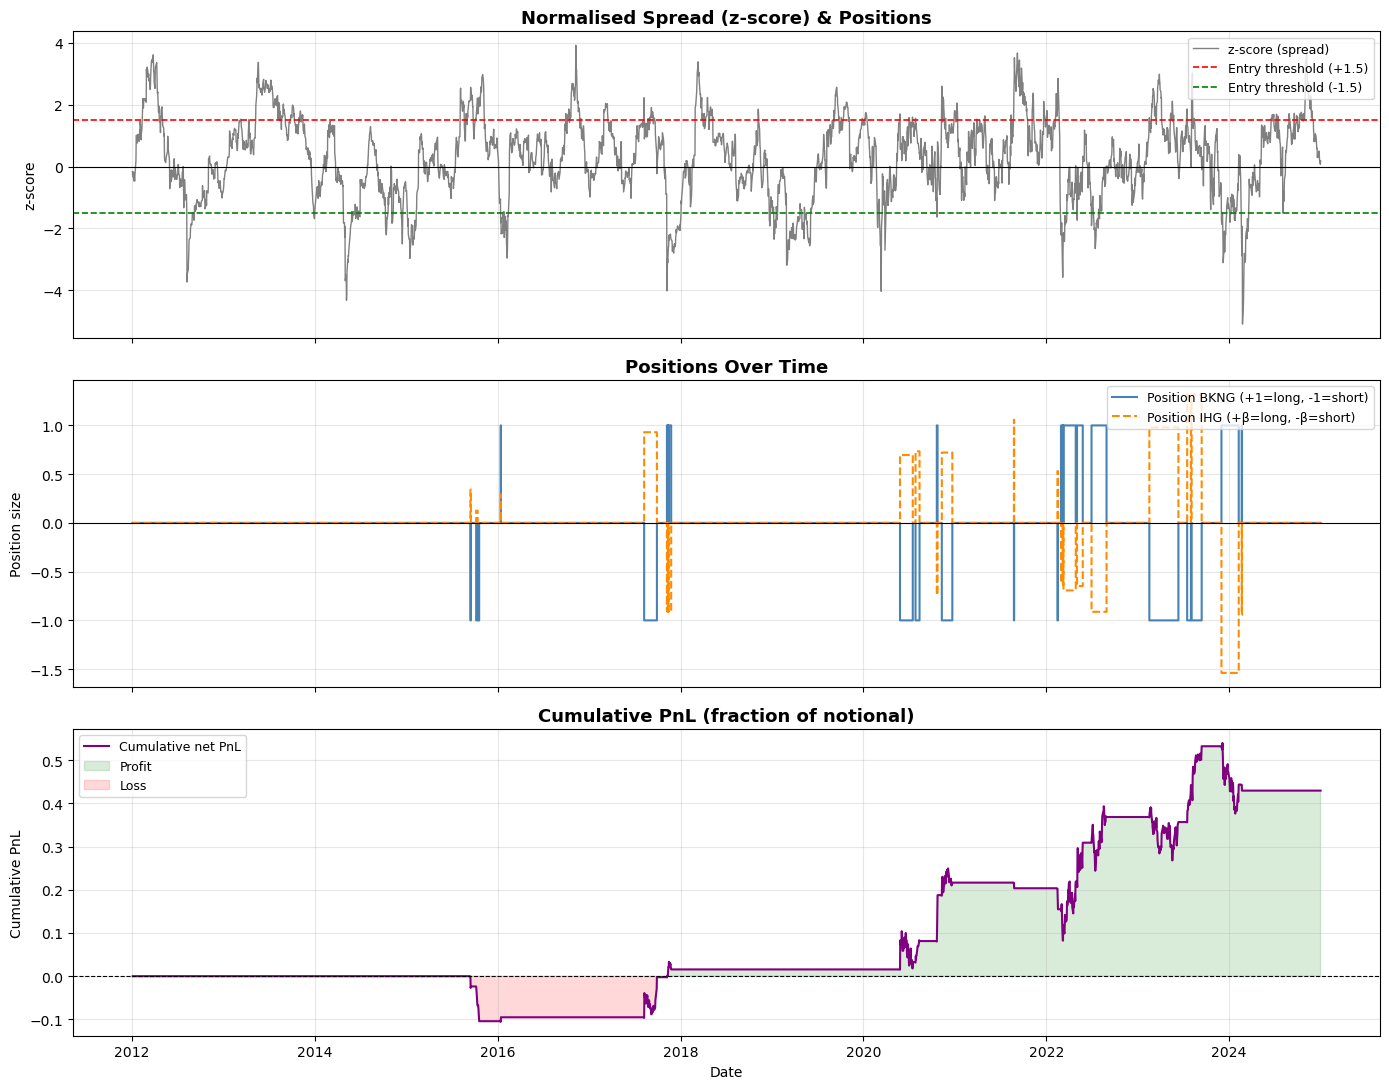

Sharpe — full-sample (look-ahead bias):       0.5648
Sharpe — rolling, no filter:                  0.0428
Sharpe — rolling + cointegration filter:      -0.1849


In [42]:
# ── Rolling trading loop WITH cointegration filter ──────────────────────────
long_A  = False
short_A = False

post_warmup_index = data_most_coint_pair.index[window_coint:]
n_trading = len(post_warmup_index)

pos_A_cf = np.zeros(n_trading)
pos_B_cf = np.zeros(n_trading)

for i, date in enumerate(post_warmup_index):

    # Carry forward previous day's position
    if i > 0:
        pos_A_cf[i] = pos_A_cf[i-1]
        pos_B_cf[i] = pos_B_cf[i-1]

    # ── Cointegration gate: if p-value ≥ threshold → not cointegrated → close & skip ───
    if rolling_coint_pval.loc[date] >= coint_pvalue_threshold or pd.isna(rolling_coint_pval.loc[date]):
        if long_A or short_A:           # forced exit when relationship breaks down
            pos_A_cf[i] = 0;  pos_B_cf[i] = 0
            long_A = False;   short_A = False
        continue                        # no new signal

    val = rolling_spread_cf.loc[date]
    b   = rolling_beta_cf.loc[date]

    # ── Standard z-score trading logic ──────────────────────────────────────
    if not short_A and not long_A:
        if val >= threshold:            # spread too high → short A, long B
            pos_A_cf[i] = -1;  pos_B_cf[i] =  b;  short_A = True
        elif val <= -threshold:         # spread too low  → long A, short B
            pos_A_cf[i] =  1;  pos_B_cf[i] = -b;  long_A  = True
    elif short_A and val < 0:           # mean-reverted → close
        pos_A_cf[i] = 0;  pos_B_cf[i] = 0;  short_A = False
    elif long_A  and val >= 0:          # mean-reverted → close
        pos_A_cf[i] = 0;  pos_B_cf[i] = 0;  long_A  = False

# ── Build positions DataFrame ─────────────────────────────────────────────
cf_pos_A     = pd.Series(pos_A_cf, index=post_warmup_index, name=ticker_A)
cf_pos_B     = pd.Series(pos_B_cf, index=post_warmup_index, name=ticker_B)
cf_positions = pd.concat([cf_pos_A, cf_pos_B], axis=1)

# ── PnL ───────────────────────────────────────────────────────────────────
cf_price_df   = data_raw[tickers_pair].reindex(post_warmup_index)
cf_returns_df = cf_price_df.pct_change()
cf_spread_df  = spread.reindex(post_warmup_index)

cf_simpletrade = Simple_Pair_Trading(
    data_most_coint_pair[ticker_A], data_most_coint_pair[ticker_B],
    rolling_spread_cf.dropna(), alpha, rolling_beta_cf.dropna().mean(), threshold
)
cf_cum_pnl, cf_sharpe = cf_simpletrade.pnl_calculations(
    cf_positions, cf_price_df, cf_returns_df, cf_spread_df
)

# ── Plot (NaN spread replaced by 0 during non-cointegrated periods) ────────
cf_zscore_plot = rolling_spread_cf.reindex(post_warmup_index).fillna(0)
plot_wealth_positions_spread(
    data_most_coint_pair.reindex(post_warmup_index),
    cf_zscore_plot, threshold, cf_positions, cf_cum_pnl
)

# ── Comparison ────────────────────────────────────────────────────────────
print(f"Sharpe — full-sample (look-ahead bias):       {sharpe_ratio:.4f}")
print(f"Sharpe — rolling, no filter:                  {rolling_sharpe:.4f}")
print(f"Sharpe — rolling + cointegration filter:      {cf_sharpe:.4f}")


to do : implement optimal threshold (look slides), kalman filter for estimating alpha and beta

---
*End of Project 1*